# Exploratory Data Analysis

This notebook explores the cleaned heart disease dataset and examines the relationship between the features and the target variable.

Target:
0 = Lower heart-disease risk class
1 = Higher heart-disease risk class

In [16]:
# Import libraries for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Cleaned Dataset

Load the dataset prepared during the Data Cleaning stage.

In [ ]:
import pandas as pd

# Load the cleaned heart disease dataset
new_df = pd.read_csv("../data/cleaned/heart_disease_cleaned.csv")

new_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [5]:
import pandas as pd

# Load the cleaned heart disease dataset
new_df = pd.read_csv("../data/cleaned/heart_disease_cleaned.csv")

new_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


## Dataset Overview

Check the structure and basic information of the cleaned dataset.

In [6]:
# Display the number of rows and columns
print("Dataset shape:", new_df.shape)

# Display the column names
print("\nColumns:")
print(new_df.columns.tolist())

# Display data types and non-null values
print("\nDataset information:")
new_df.info()

Dataset shape: (1024, 15)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  

In [7]:
# Count records in each target class
print(new_df["target_binary"].value_counts())

# Calculate the percentage of each target class
print("\nTarget percentages:")
print(
    new_df["target_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_binary
0    554
1    470
Name: count, dtype: int64

Target percentages:
target_binary
0    54.1
1    45.9
Name: proportion, dtype: float64


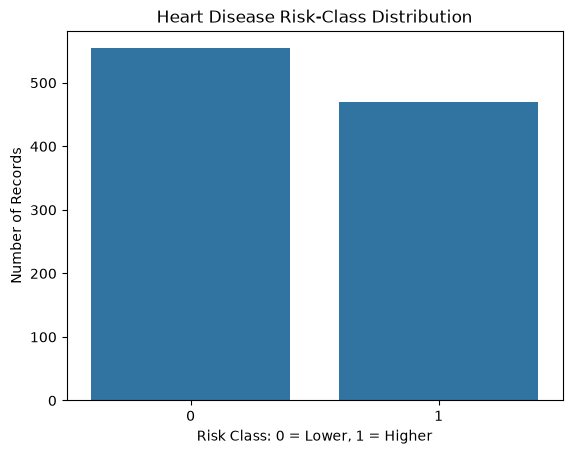

In [13]:
# Draw the target-class distribution
sns.countplot(
    data=new_df,
    x="target_binary"
)

plt.title("Heart Disease Risk-Class Distribution")
plt.xlabel("Risk Class: 0 = Lower, 1 = Higher")
plt.ylabel("Number of Records")
plt.show()

## Chest-Pain Type Analysis

Explore the distribution of chest-pain types across the two risk classes.

In [17]:
# Count chest-pain types for each risk class

cp_counts = pd.crosstab(
    new_df["cp"],
    new_df["target_binary"]
)

# Display the counts
print(cp_counts)

target_binary    0    1
cp                     
1               61   25
2              132   28
3              232   61
4              129  356


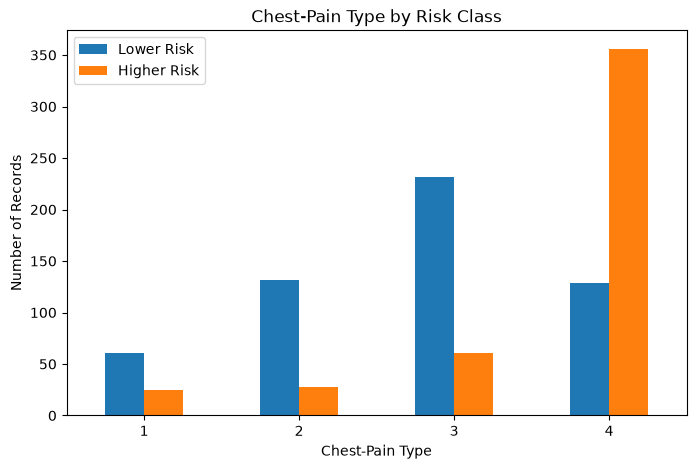

In [18]:
# Plot chest-pain types by risk class

cp_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Chest-Pain Type by Risk Class")
plt.xlabel("Chest-Pain Type")
plt.ylabel("Number of Records")
plt.legend(["Lower Risk", "Higher Risk"])
plt.xticks(rotation=0)
plt.show()

## Maximum Heart Rate Analysis

Explore the maximum heart rate distribution across the two risk classes.

In [19]:
# Compare the average maximum heart rate between risk classes

new_df.groupby("target_binary")["thalach"].mean()

target_binary
0    158.371049
1    139.344384
Name: thalach, dtype: float64

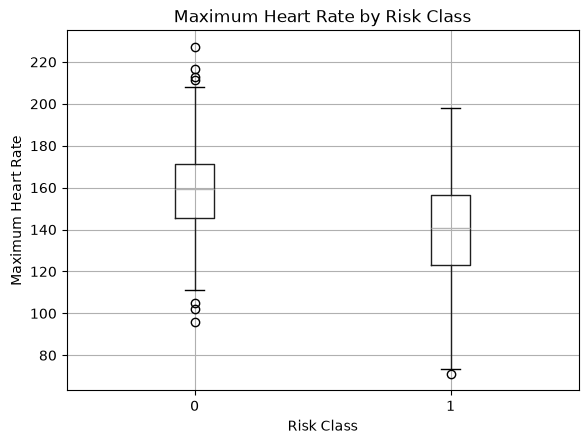

In [20]:
# Compare maximum heart rate between risk classes using a boxplot

new_df.boxplot(
    column="thalach",
    by="target_binary"
)

plt.title("Maximum Heart Rate by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Maximum Heart Rate")
plt.show()

## Cholesterol Analysis

Explore cholesterol levels across the two risk classes.

In [21]:
# Compare the average cholesterol level between risk classes

new_df.groupby("target_binary")["chol"].mean()

target_binary
0    242.101230
1    252.698274
Name: chol, dtype: float64

## Cholesterol Analysis Findings

The graph compares cholesterol levels between Risk Class 0 and Risk Class 1.

- The middle line shows the median cholesterol level.
- The box shows the middle 50% of the data.
- The vertical lines show the normal range of the data.
- The small circles show outliers, which are values far from the main data.

Class 1 has a slightly higher median cholesterol level than Class 0.

The two classes overlap, so cholesterol alone does not clearly separate the two risk classes.

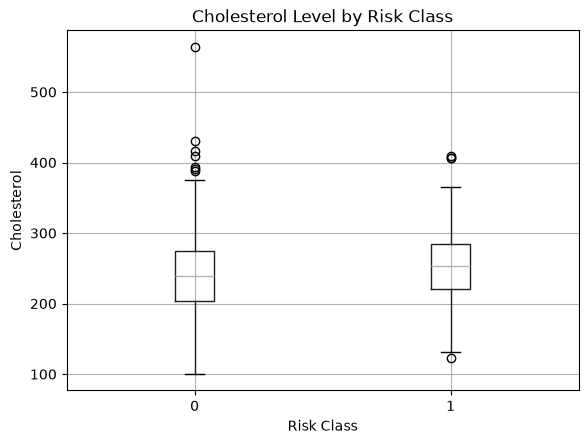

In [22]:
# Compare cholesterol levels between risk classes

new_df.boxplot(
    column="chol",
    by="target_binary"
)

plt.title("Cholesterol Level by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Cholesterol")
plt.show()

## Resting Blood Pressure Analysis

This analysis compares resting blood pressure between the two risk classes.

The boxplot shows:
- Median blood pressure
- Middle 50% of the values
- Data range
- Outliers

In [23]:
# Compare the average resting blood pressure between risk classes

new_df.groupby("target_binary")["trestbps"].mean()

target_binary
0    128.90465
1    134.51262
Name: trestbps, dtype: float64

These five variables are continuous numerical features:

In [25]:
# Define the continuous numerical features

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [27]:

#These variables are numbers in the CSV, but they represent categories:

# Categorical features represented using numbers
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


In [28]:

#Combine the selected features:

# Combine all input features
features = numeric_features + categorical_features

print("Selected features:", features)

#We intentionally exclude:

#target_binary: the answer being predicted
#num: the original heart-disease class used to create the binary target

Selected features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


 Create X and y

In [30]:

# X contains the input features
X = new_df[features].copy()

# y contains the class to predict
y = new_df["target_binary"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

#Expected shapes:

#X shape: (1024, 13)
#y shape: (1024,)

     

X shape: (1024, 13)
y shape: (1024,)


## Final Data Check

Check the selected features and target before moving to model training.

In [31]:
# Check missing values in the selected features
print("Missing values in X:")
print(X.isna().sum())

# Check missing values in the target
print("\nMissing values in y:")
print(y.isna().sum())

Missing values in X:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          0
thal        0
dtype: int64

Missing values in y:
0


In [32]:
# Check duplicate rows in the selected features
print("Duplicate rows in X:", X.duplicated().sum())

Duplicate rows in X: 0


In [33]:
# Display the target classes
print("Target classes:")
print(y.value_counts())

Target classes:
target_binary
0    554
1    470
Name: count, dtype: int64


In [34]:
# Display the final shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1024, 13)
y shape: (1024,)


## Conclusion

The cleaned dataset was explored and the main numerical and categorical features were identified.

The target variable was separated from the input features.

The final feature matrix `X` and target variable `y` are ready for the Model Training stage.